In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import arviz as az

# import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

Comparing inferred remnant spins from inclined injections for both system masses:

In [3]:
fit_l = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot72/220+221_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_inclined/engine/1126259462.423000/config.ini')
fit_h = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot330/220+221_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined/engine/1126259462.423000/config.ini')

In [4]:
coll_l = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot72/220+221_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_inclined/engine/*/result.nc')
coll_h = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot330/220+221_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [5]:
mf_l = coll_l[0].config['model']['m_min'] * 2
mf_h = coll_h[0].config['model']['m_min'] * 2

mf_l, mf_h

(68.51542214, 314.02901814)

In [6]:
coll_l.reindex_by_t0(reference_time=1126259462.423, reference_mass=mf_l, decimals=0)
coll_h.reindex_by_t0(reference_time=1126259462.423, reference_mass=mf_h, decimals=0)

In [7]:
df_l = coll_l.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
df_h = coll_h.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [8]:
# end = 12

# g = sns.histplot(df_l[df_l['run']<=end], x='chi', hue='run', palette=sns.color_palette('Oranges', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, element='step', stat='density', legend=False, bins=30)
# sns.histplot(df_h[df_h['run']<=end], x='chi', hue='run', palette=sns.color_palette('Oranges', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, element='step', alpha=0, stat='density', legend=False, bins=30)

# g.legend(list(g.collections), df_l['run'].unique(), frameon=False, title='start time [M]', ncol=2)
# plt.xlabel('$\chi_{\mathrm{f}}$')

Text(0.5, 1.0, 'SXS_BBH_1155 (inclined) fit w/ Kerr 220+221')

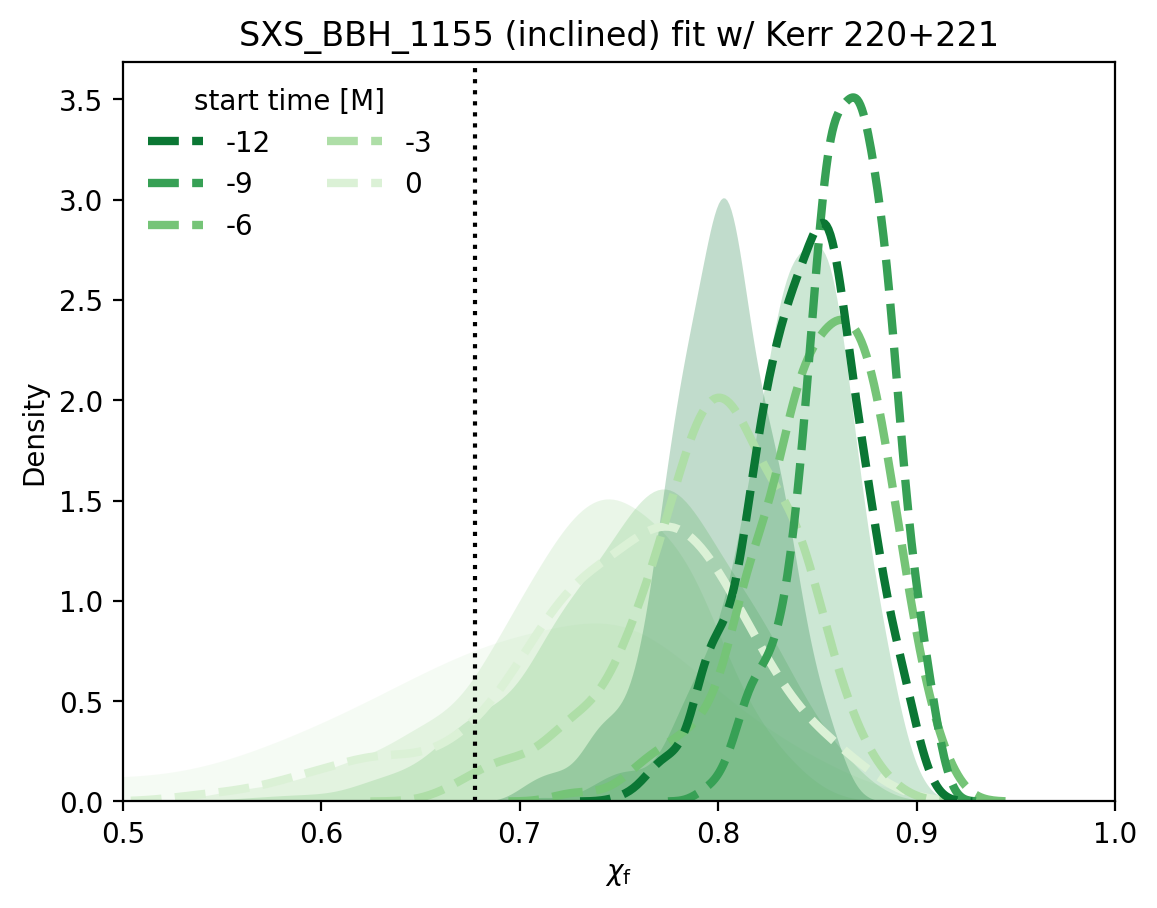

In [13]:
end = 0

sns.kdeplot(df_l[df_l['run']<=end], x='chi', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, fill=True, legend=False)
g = sns.kdeplot(df_h[df_h['run']<=end], x='chi', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, ls='--', fill=False)

g.legend(list(g.get_lines())[::-1], [int(r) for r in df_l['run'].unique()], frameon=False, title='start time [M]', ncol=2)
plt.xlabel('$\chi_{\mathrm{f}}$')

plt.xlim(0.5, 1)
plt.axvline(0.67721823, c='k', ls=':')
plt.title('SXS_BBH_1155 (inclined) fit w/ Kerr 220+221')

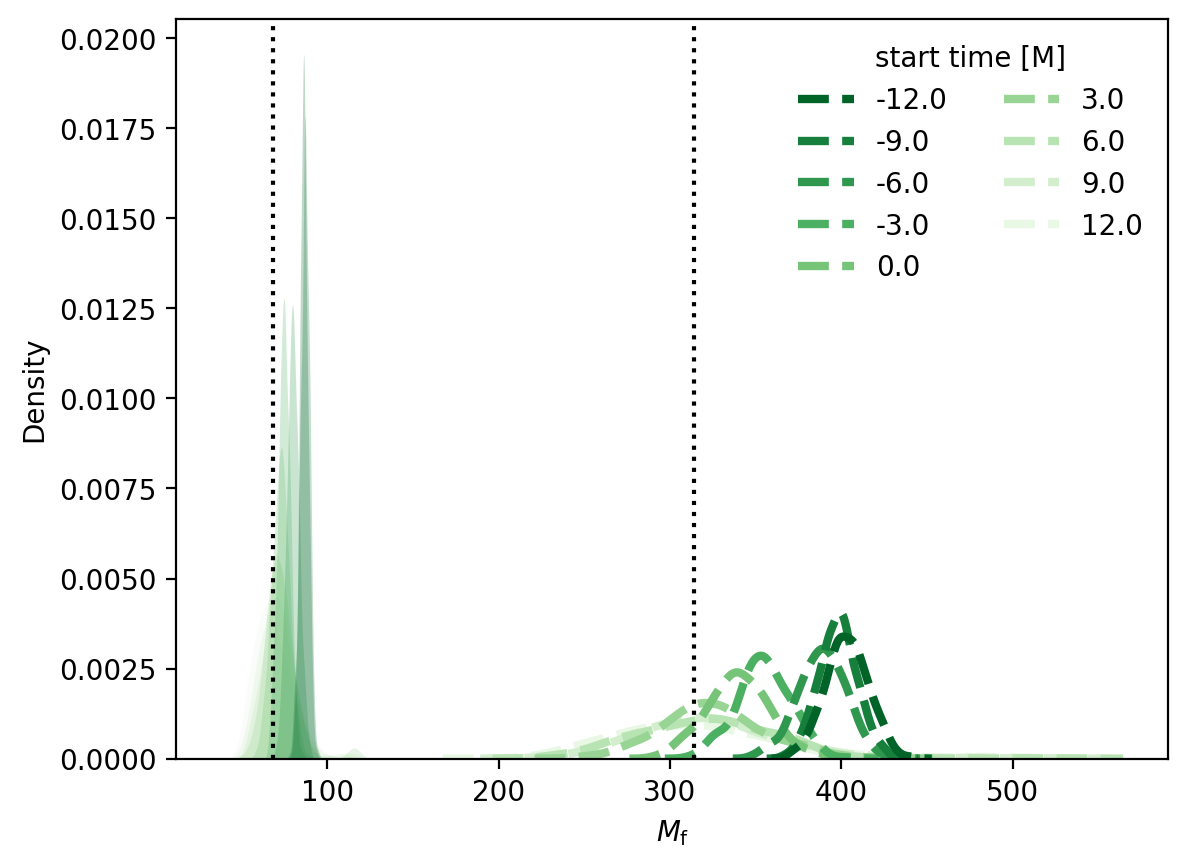

In [10]:
end = 12

sns.kdeplot(df_l[df_l['run']<=end], x='m', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, fill=True, legend=False)
g = sns.kdeplot(df_h[df_h['run']<=end], x='m', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, ls='--', fill=False)

g.legend(list(g.get_lines())[::-1], df_l['run'].unique(), frameon=False, title='start time [M]', ncol=2)
plt.xlabel('$M_{\mathrm{f}}$')

plt.axvline(mf_l, color='k', ls=':')
plt.axvline(mf_h, color='k', ls=':')